<a href="https://colab.research.google.com/github/Muhammad-Musharraf/Machine-Learning/blob/main/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [73]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns



In [74]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [75]:
# Read the Dataset

df=pd.read_csv("/content/drive/MyDrive/House Price Prediction Dataset.csv")

In [76]:
# First 5 row of the data

df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [77]:
# take a 5 sample of the data

df.sample(5)

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
1642,1643,1350,4,4,1,1996,Urban,Good,No,724035
1764,1765,3851,2,3,2,2008,Downtown,Excellent,No,63698
1237,1238,4633,4,4,1,1934,Suburban,Poor,No,119806
542,543,1039,5,3,2,1930,Urban,Poor,Yes,305745
606,607,1829,5,3,3,1932,Urban,Fair,No,294437


In [78]:
# Shape of the Dataset

df.shape

(2000, 10)

In [79]:
# preview of the data

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [80]:
# mathhematical explaination

df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [81]:
# Check all Null values

df.isnull().sum()

,0
Id,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,0


In [82]:
# Check All the Duplicated Values of the Data

df.duplicated().sum()

np.int64(0)

In [83]:
# Check all Data Types

df.dtypes

,0
Id,int64
Area,int64
Bedrooms,int64
Bathrooms,int64
Floors,int64
YearBuilt,int64
Location,object
Condition,object
Garage,object
Price,int64


In [84]:
df.value_counts()

,,,,,,,,,,count
Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price,
1984,3956,4,4,1,1971,Urban,Poor,Yes,581992,1
1983,4682,3,3,3,1961,Urban,Excellent,No,597685,1
1982,4076,5,4,2,1985,Rural,Excellent,No,663529,1
1981,3771,2,2,1,1989,Suburban,Fair,No,890271,1
1980,1531,5,3,3,1963,Rural,Poor,No,970200,1
...,...,...,...,...,...,...,...,...,...,...
5,4926,1,4,2,1975,Downtown,Fair,Yes,636056,1
4,966,4,2,2,1902,Suburban,Fair,Yes,244020,1
3,3592,2,2,3,1938,Downtown,Good,No,266746,1


# Data Cleaning:
 > I check each column and Overall dataset. data is clean there is no null values and duplicated values and data types of all the column of the dataset is correct and again i checked each column for unique function.  

# Check Unique Values of All Columns.

In [85]:
df['Bathrooms'].unique()

array([4, 2, 1, 3])

In [86]:
df['Bathrooms'].value_counts()

,count
Bathrooms,
3,524
4,521
2,494
1,461


In [87]:
df['Condition'].unique()

array(['Excellent', 'Good', 'Fair', 'Poor'], dtype=object)

In [88]:
df['Floors'].unique()

array([3, 2, 1])

In [89]:
df['Garage'].unique()

array(['No', 'Yes'], dtype=object)

In [90]:
df['YearBuilt'].unique()

array([1970, 1958, 1938, 1902, 1975, 1906, 1948, 1925, 1932, 2000, 1947,
       1978, 1901, 2004, 1931, 1903, 1919, 2013, 2016, 1935, 1927, 1976,
       1900, 1959, 1955, 1934, 2011, 1929, 1953, 2020, 1954, 1988, 1979,
       1957, 1982, 1964, 1968, 1950, 1921, 1987, 2006, 2008, 2015, 1952,
       1999, 1967, 1951, 1981, 1949, 1940, 1917, 1965, 1920, 1943, 2002,
       1946, 1928, 1989, 1984, 1916, 1930, 2014, 1972, 1994, 1977, 2009,
       1913, 1996, 1998, 2010, 1983, 2022, 1915, 1911, 2018, 1904, 1980,
       2021, 2005, 1973, 1942, 1944, 1908, 1961, 1956, 1924, 1914, 1905,
       2019, 1941, 1992, 1974, 1963, 2001, 1991, 1936, 1907, 1997, 2007,
       2017, 1966, 1945, 1912, 1986, 1960, 1995, 1933, 1969, 1923, 2012,
       1910, 2003, 1993, 2023, 1918, 1971, 1926, 1939, 1922, 1937, 1909,
       1990, 1962, 1985])

In [91]:
df['Area'].unique()

array([1360, 4272, 3592, ...,  865, 2174, 4062])

In [92]:
df['Price'].unique()

array([149919, 424998, 266746, ..., 476925, 161119, 482525])

In [93]:
df['Location'].unique()

array(['Downtown', 'Suburban', 'Urban', 'Rural'], dtype=object)

<Axes: ylabel='Price'>

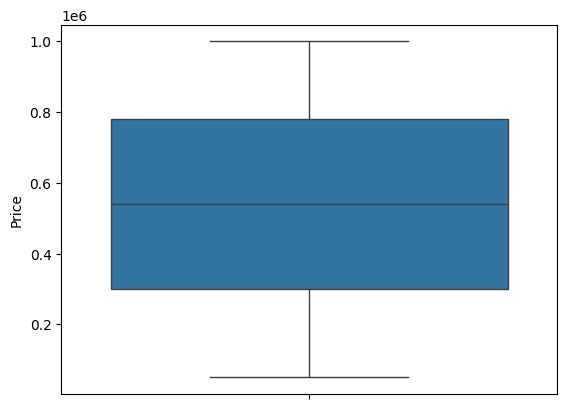

In [94]:
# Check The Outliers in the price column
sns.boxplot(df['Price'])

<Axes: ylabel='Area'>

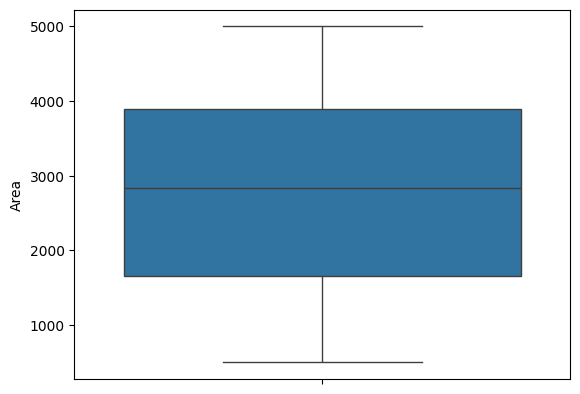

In [95]:
# Check the outliers in the Area Column
sns.boxplot(df['Area'])

In [96]:
df=df.drop(['Id'],axis=1)

In [97]:
df=df.drop(['YearBuilt'],axis=1)

# Data Processing

In [98]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split

In [99]:
x=df.drop(["Price"],axis=1)
y=df["Price"]

In [100]:
x

,Area,Bedrooms,Bathrooms,Floors,Location,Condition,Garage
0,1360,5,4,3,Downtown,Excellent,No
1,4272,5,4,3,Downtown,Excellent,No
2,3592,2,2,3,Downtown,Good,No
3,966,4,2,2,Suburban,Fair,Yes
4,4926,1,4,2,Downtown,Fair,Yes
...,...,...,...,...,...,...,...
1995,4994,5,4,3,Suburban,Poor,No
1996,3046,5,2,1,Suburban,Poor,Yes
1997,1062,5,1,2,Rural,Poor,No
1998,4062,3,1,2,Urban,Excellent,Yes


In [101]:
y

,Price
0,149919
1,424998
2,266746
3,244020
4,636056
...,...
1995,295620
1996,580929
1997,476925
1998,161119


In [102]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [103]:
x_train.shape,x_test.shape

((1600, 7), (400, 7))

| Column Name   | Data Type              | Example Values                   | Encoding             | Scaling       | Reason                    |
| ------------- | ---------------------- | -------------------------------- | -------------------- | ------------- | ------------------------- |
| **Condition** | Ordinal Categorical    | Poor, Average, Good, Excellent   | **Ordinal Encoding** | ❌ No          | Has a clear order         |
| **Location**  | Nominal Categorical    | Downtown, Urban, Suburban, Rural | **One-Hot Encoding** | ❌ No          | No natural order          |
| **Floors**    | Numerical (Discrete)   | 1, 2, 3                          | ❌ No                 | ✅ Yes         | Numeric magnitude matters |
| **Bedrooms**  | Numerical (Discrete)   | 1–6                              | ❌ No                 | ✅ Yes         | Quantity-based feature    |
| **Bathrooms** | Numerical (Discrete)   | 1–5                              | ❌ No                 | ✅ Yes         | Quantity-based feature    |
| **Area**      | Numerical (Continuous) | 500–5000 sqft                    | ❌ No                 | ✅ Yes         | Large range values        |
| **Price**     | Numerical (Continuous) | 5M–50M                           | ❌ No                 | ❌ No (Target) | Target variable           |


In [104]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder

In [105]:
scalar=StandardScaler()


In [106]:
scalar.fit(x[['Floors','Bedrooms','Bathrooms']])

StandardScaler()

In [107]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(drop='first', sparse_output=False)
encoded = ohe.fit_transform(x[['Location', 'Garage']])


In [108]:
encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(['Location', 'Garage'])
)


In [109]:
df.head()

,Area,Bedrooms,Bathrooms,Floors,Location,Condition,Garage,Price
0,1360,5,4,3,Downtown,Excellent,No,149919
1,4272,5,4,3,Downtown,Excellent,No,424998
2,3592,2,2,3,Downtown,Good,No,266746
3,966,4,2,2,Suburban,Fair,Yes,244020
4,4926,1,4,2,Downtown,Fair,Yes,636056


In [110]:
df['Condition'].unique()

array(['Excellent', 'Good', 'Fair', 'Poor'], dtype=object)

In [111]:
condition_order=['Poor','Fair','Good','Excellent']
oe=OrdinalEncoder(categories=[condition_order])


In [112]:
df['Condition']=oe.fit_transform(df[['Condition']])

In [113]:
df.head()

,Area,Bedrooms,Bathrooms,Floors,Location,Condition,Garage,Price
0,1360,5,4,3,Downtown,3.0,No,149919
1,4272,5,4,3,Downtown,3.0,No,424998
2,3592,2,2,3,Downtown,2.0,No,266746
3,966,4,2,2,Suburban,1.0,Yes,244020
4,4926,1,4,2,Downtown,1.0,Yes,636056


In [114]:
oe=OrdinalEncoder()
oe.fit(x[["Condition"]])

OrdinalEncoder()

In [115]:
nom=MinMaxScaler()
nom.fit(x[["Area"]])

MinMaxScaler()

In [116]:


colums_trans = make_column_transformer(
    (OneHotEncoder(drop='first', sparse_output=False), ['Location', 'Garage']),
    (OrdinalEncoder(), ['Condition']),
    (MinMaxScaler(), ['Area']),
    (StandardScaler(), ['Floors', 'Bedrooms', 'Bathrooms']),
    remainder='passthrough'
)


In [117]:
colums_trans

ColumnTransformer(remainder='passthrough',
                  transformers=[('onehotencoder',
                                 OneHotEncoder(drop='first',
                                               sparse_output=False),
                                 ['Location', 'Garage']),
                                ('ordinalencoder', OrdinalEncoder(),
                                 ['Condition']),
                                ('minmaxscaler', MinMaxScaler(), ['Area']),
                                ('standardscaler', StandardScaler(),
                                 ['Floors', 'Bedrooms', 'Bathrooms'])])

In [118]:
x_train_tranform=colums_trans.fit_transform(x_train)
x_test_tranform=colums_trans.fit_transform(x_test)

# Modeling

In [119]:
# Linear Regression Models
from sklearn.linear_model import LinearRegression

# Tree-Based Regression Models
from sklearn.tree import DecisionTreeRegressor

# Distance / Kernel-Based Models
from sklearn.neighbors import KNeighborsRegressor


#Boosting
from lightgbm import LGBMRegressor


In [120]:
# Objects of Models

lr   = LinearRegression()
dt   = DecisionTreeRegressor()
knn  = KNeighborsRegressor()
lgbm = LGBMRegressor()

In [121]:

regressors={
    "LR":lr,
    "DT":dt,
    "KNN":knn,
    "LGBM":lgbm
}

In [122]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [123]:
def train_regessor(regressors,x_train,x_test,y_train,y_test,name):
  # Train The Regressor
  regressors.fit(x_train,y_train)
  # Make Prediction
  y_pred=regressors.predict(x_test)

  # Calculate metrics
  mse=mean_squared_error(y_test,y_pred)
  mae=mean_absolute_error(y_test,y_pred)
  r2=r2_score(y_test,y_pred)
  return mse,mae,r2


In [124]:
mse_scores = []
mae_scores = []
r2_scores = []

# Loop over each regressor in the dictionary
for name, reg in regressors.items():
    # Train regressor and get metrics
    current_mse, current_mae, current_r2 = train_regessor(reg,x_train_tranform, x_test_tranform, y_train, y_test, name)

    # Print metrics
    print(f'Name: {name}')
    print(f'MSE: {current_mse}')
    print(f'MAE: {current_mae}')
    print(f'R2: {current_r2}')
    print('----------------------------')

    # Store metrics in lists
    mse_scores.append(current_mse)
    mae_scores.append(current_mae)
    r2_scores.append(current_r2)

Name: LR
MSE: 78149382770.1017
MAE: 242987.90230195143
R2: -0.004505906539616689
----------------------------
Name: DT
MSE: 168235749840.9725
MAE: 337758.2275
R2: -1.1624457982415657
----------------------------
Name: KNN
MSE: 98682673820.6819
MAE: 267717.3325
R2: -0.2684339301515428
----------------------------
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000320 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 282
[LightGBM] [Info] Number of data points in the train set: 1600, number of used features: 9
[LightGBM] [Info] Start training from score 536183.700000
Name: LGBM
MSE: 92069905409.56013
MAE: 255913.94953115194
R2: -0.18343562700318183
----------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [125]:
from sklearn.pipeline import make_pipeline

# Make Pipeline

In [126]:
pipe1=make_pipeline(colums_trans,lr)
pipe2=make_pipeline(colums_trans,dt)
pipe3=make_pipeline(colums_trans,knn)
pipe4=make_pipeline(colums_trans,lgbm)

# Fitting The Model

In [127]:
pipe1.fit(x_train,y_train)
pipe2.fit(x_train,y_train)
pipe3.fit(x_train,y_train)
pipe4.fit(x_train,y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000079 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 282
[LightGBM] [Info] Number of data points in the train set: 1600, number of used features: 9
[LightGBM] [Info] Start training from score 536183.700000


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['Location', 'Garage']),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(),
                                                  ['Condition']),
                                                 ('minmaxscaler',
                                                  MinMaxScaler(), ['Area']),
                                                 ('standardscaler',
                                                  StandardScaler(),
                                                  ['Floors', 'Bedrooms',
                                                   'Bathrooms'])])),
                ('lgbmregressor', LGBMRegressor())])

In [128]:
y_pred_pipe1=pipe1.predict(x_test)
y_pred_pipe2=pipe2.predict(x_test)
y_pred_pipe3=pipe3.predict(x_test)
y_pred_pipe4=pipe4.predict(x_test)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


# Checking R2-Score

In [129]:

print(r2_score(y_test,y_pred_pipe1))
print(r2_score(y_test,y_pred_pipe2))
print(r2_score(y_test,y_pred_pipe3))
print(r2_score(y_test,y_pred_pipe4))

-0.004786043537768903
-1.07422358460808
-0.272930956959605
-0.1889211729020095


In [130]:
scores=[]
for i in range(1000):
    x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1,random_state=i)
    lr = LinearRegression()
    pipe=make_pipeline(colums_trans,lr)
    pipe.fit(x_train,y_train)
    y_pred=pipe.predict(x_test)
    scores.append(r2_score(y_test,y_pred))

In [131]:
np.argmax(scores)

np.int64(166)

In [132]:
scores[np.argmax(scores)]

0.024847333294326313

In [133]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=np.argmax(scores))
lr= LinearRegression()
pipe=make_pipeline(colums_trans,lr)
pipe.fit(x_train,y_train)
y_pred=pipe.predict(x_test)
r2_score(y_test,y_pred)


0.013340776250956865

In [134]:
df.head()

,Area,Bedrooms,Bathrooms,Floors,Location,Condition,Garage,Price
0,1360,5,4,3,Downtown,3.0,No,149919
1,4272,5,4,3,Downtown,3.0,No,424998
2,3592,2,2,3,Downtown,2.0,No,266746
3,966,4,2,2,Suburban,1.0,Yes,244020
4,4926,1,4,2,Downtown,1.0,Yes,636056
